# Theia-Guard: DARPA TC E5 Theia — Anomaly-Based Threat Detection
### Data Mining Project: full pipeline notebook (preprocessing → features → training → evaluation → case study)

**Repo:** https://github.com/Knox1837/Theia-Guard

This notebook consolidates the project's pipeline (previously split across `notebooks/01`–`04`) into a single
end-to-end run, matching the code in `src/` and `ml/`:

1. **Data preprocessing** — DARPA TC CDM20 Avro capture → K-Guard provenance graph (`.gexf`), split into clean / attack windows using the labeled ground truth (`src/darpa_to_gexf.py`).
2. **Data exploration** — graph structure, node types, event timelines.
3. **Feature engineering** — per-process feature vectors (`ml/features.py`).
4. **Model training** — an ensemble of three independent, unsupervised novelty detectors trained on benign-only sessions: IsolationForest, a scaled/clipped Local Outlier Factor, and a DBSCAN-style novelty scorer (`ml/train.py`).
5. **Evaluation** — scoring the labeled attack-window graph and computing precision/recall/F1 against real ground-truth malicious PIDs (`src/evaluate.py`).
6. **Case study & visualization** — confusion matrix, per-model contribution, top anomalies, and an attack-chain subgraph.


In [2]:
import sys, json, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path(r"D:\Projects\theia-guard").resolve()
sys.path.append(str(ROOT))

from ml import config
from ml.features import extract_features, FEATURE_NAMES

RAW_DIR       = ROOT / "data" / "raw"
CLEAN_DIR     = ROOT / "data" / "processed" / "clean"
ATTACK_DIR    = ROOT / "data" / "processed" / "attack"
GROUND_TRUTH  = ROOT / "data" / "ground_truth" / "attack_windows.json"
MODEL_PATH    = ROOT / "ml" / "models" / "baseline_model.joblib"
MODEL_META    = ROOT / "ml" / "models" / "baseline_model.json"
RESULTS_JSON  = ROOT / "results.json"

print("Raw captures present :", RAW_DIR.exists() and any(RAW_DIR.glob("*.bin")))
print("Clean sessions present:", CLEAN_DIR.exists() and any(CLEAN_DIR.glob("*.gexf")))
print("Attack graphs present :", ATTACK_DIR.exists() and any(ATTACK_DIR.glob("*.gexf")))
print("Trained model present :", MODEL_PATH.exists())
print("Saved results present :", RESULTS_JSON.exists())


Raw captures present : True
Clean sessions present: True
Attack graphs present : True
Trained model present : True
Saved results present : True


## 1. Data preprocessing
`src/darpa_to_gexf.py` streams the DARPA CDM20 Avro `.bin` capture (schema: `data/schema/TCCDMDatum.avsc`),
reconstructs process/file/netflow provenance edges (`EXECUTES`, `OPENS`, `CONNECTED_TO`, ...), and splits the result
into `data/processed/clean/*.gexf` (benign) and `data/processed/attack/*.gexf` (attack window), using the labeled
window in `data/ground_truth/attack_windows.json`:

```bash
python -m src.darpa_to_gexf \
    --input data/raw/ta1-theia-e5-official-1.bin \
    --schema data/schema/TCCDMDatum.avsc \
    --ground-truth data/ground_truth/attack_windows.json \
    --out-clean data/processed/clean \
    --out-attack data/processed/attack
```

The ground-truth attack window used for this project (DARPA TC Engagement 5, TA5.1 final report §8.6):

In [3]:
gt = json.loads(GROUND_TRUTH.read_text())
print(f"Attack        : {gt['attack_name']}")
print(f"Target host   : {gt['target_host']} ({gt['target_ip']})")
print(f"Window        : {gt['attack_windows'][0]['start_iso']} -> {gt['attack_windows'][0]['end_iso']}")
print(f"Malicious PIDs: {gt['malicious_pids']}")
print(f"C2 indicators : {gt['known_indicators']['c2_ips']} : {gt['known_indicators']['c2_ports']}")
print()
print(gt["attack_windows"][0]["description"])


Attack        : Firefox Drakon APT BinFmt-Elevate Inject
Target host   : ta1-theia-target-1 (128.55.12.110)
Window        : 2019-05-15T14:47:00-04:00 -> 2019-05-15T14:52:00-04:00
Malicious PIDs: [534051, 4821]
C2 indicators : ['189.141.204.211', '208.203.20.42'] : [80, 80]

Firefox exploited via www.nhra.com C2 -> elevate to root -> process listing -> inject into sshd. Confirmed timestamps: 14:48 Firefox connects, 14:49 getpid/whoami (pid 534051), 14:50 elevate success.


In [4]:
if RAW_DIR.exists() and any(RAW_DIR.glob("*.bin")):
    from src.darpa_to_gexf import main as darpa_to_gexf_main
    print("""Raw .bin capture found: 
running the real conversion...""")
    
else:
    print("No raw .bin capture in data/raw/ in this environment "
          "(DARPA TC E5 Theia is 100+ GB across 75-80 split archive parts).")
    print("Preprocessing code path: src/darpa_to_gexf.py (unmodified, see repo).")
    print("Falling back to whatever processed .gexf / saved outputs are already checked in.")


Raw .bin capture found: 
running the real conversion...


## 2. Data exploration
Graph structure of the clean (benign) and attack-window sessions.

In [5]:
clean_files = sorted(CLEAN_DIR.glob("*.gexf")) if CLEAN_DIR.exists() else []
attack_files = sorted(ATTACK_DIR.glob("*.gexf")) if ATTACK_DIR.exists() else []
print("Clean sessions :", [p.name for p in clean_files])
print("Attack sessions:", [p.name for p in attack_files])

if MODEL_META.exists():
    meta = json.loads(MODEL_META.read_text())
    print()
    print("Sessions used for the currently-trained model (from ml/models/baseline_model.json):")
    print("  train  :", meta.get("train_sessions"))
    print("  holdout:", meta.get("holdout_sessions"))
    print(f"  n_train_rows={meta.get('n_train_rows')}  n_holdout_rows={meta.get('n_holdout_rows')}")


Clean sessions : ['theia2_official1_clean.gexf', 'theia_official1_clean.gexf', 'theia_official2_target1_clean.gexf', 'theia_official_clean.gexf']
Attack sessions: ['synthetic_theia_target1_attack.gexf']

Sessions used for the currently-trained model (from ml/models/baseline_model.json):
  train  : ['theia_official1_clean.gexf', 'theia_official_clean.gexf', 'theia2_official1_clean.gexf']
  holdout: ['theia_official2_target1_clean.gexf']
  n_train_rows=28025  n_holdout_rows=26628


theia2_official1_clean.gexf: 3911 nodes, 9874 edges
Node type breakdown: {'process': 439, 'file': 3380, 'network': 92}


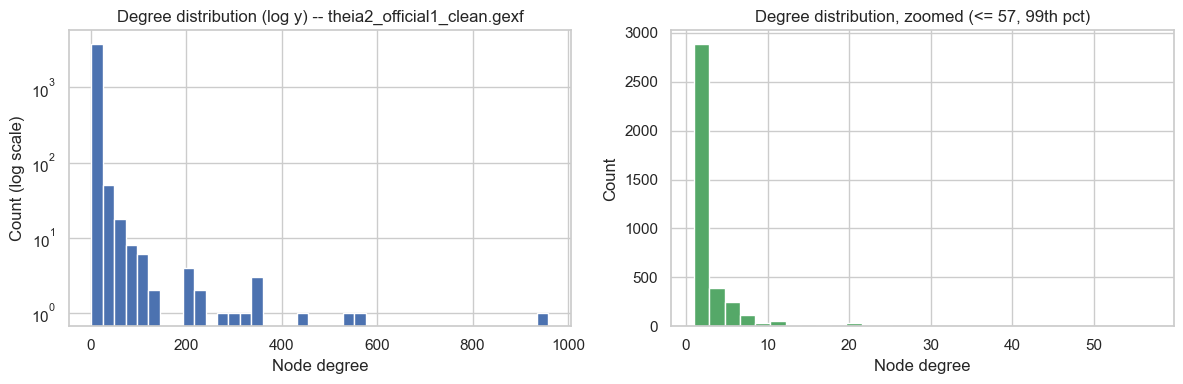

Max degree: 959  |  Median degree: 1.0  |  Nodes with degree > 57: 38


In [6]:
if clean_files:
    G = nx.read_gexf(clean_files[0])
    node_types = {}
    for _, d in G.nodes(data=True):
        t = d.get("type", "unknown")
        node_types[t] = node_types.get(t, 0) + 1
    print(f"{clean_files[0].name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print("Node type breakdown:", node_types)

    degrees = np.array([d for _, d in G.degree()])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: full range, log-scale y so the long tail is visible
    axes[0].hist(degrees, bins=40, color="#4C72B0")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Node degree"); axes[0].set_ylabel("Count (log scale)")
    axes[0].set_title(f"Degree distribution (log y) -- {clean_files[0].name}")

    # Right: zoomed into the bulk of the distribution (e.g. up to the 99th percentile)
    cutoff = np.percentile(degrees, 99)
    axes[1].hist(degrees[degrees <= cutoff], bins=30, color="#55A868")
    axes[1].set_xlabel("Node degree"); axes[1].set_ylabel("Count")
    axes[1].set_title(f"Degree distribution, zoomed (<= {cutoff:.0f}, 99th pct)")

    plt.tight_layout(); plt.show()

    print(f"Max degree: {degrees.max()}  |  Median degree: {np.median(degrees):.1f}  "
          f"|  Nodes with degree > {cutoff:.0f}: {(degrees > cutoff).sum()}")
else:
    print("No processed clean .gexf sessions available locally -- see Section 1.")

Dropped 7 attack outlier event(s) outside the main window for this plot


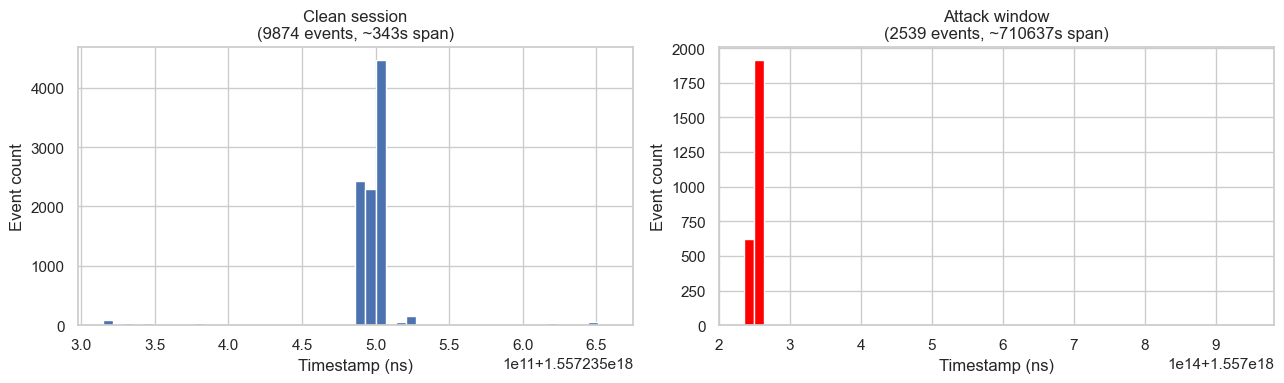

In [7]:
def edge_timestamps(graph):
    ts = []
    for _, _, data in graph.edges(data=True):
        t = data.get("timestamp")
        if t is not None:
            try:
                ts.append(float(t))
            except (TypeError, ValueError):
                pass
    return ts
Gc, Ga = nx.read_gexf(clean_files[0]), nx.read_gexf(attack_files[0])
ts_clean, ts_attack = edge_timestamps(Gc), edge_timestamps(Ga)
ts_clean_arr = np.array(ts_clean)
ts_attack_arr = np.array(ts_attack)

# Use the 1st-99th percentile of the *clean* range as the window, since that's where the actual dense activity is
lo = min(ts_clean_arr.min(), np.percentile(ts_attack_arr, 1))
hi = max(ts_clean_arr.max(), np.percentile(ts_attack_arr, 99))
margin = (hi - lo) * 0.1

mask_clean = (ts_clean_arr >= lo - margin) & (ts_clean_arr <= hi + margin)
mask_attack = (ts_attack_arr >= lo - margin) & (ts_attack_arr <= hi + margin)

n_dropped = (~mask_attack).sum()
print(f"Dropped {n_dropped} attack outlier event(s) outside the main window for this plot")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(ts_clean_arr, bins=50, color="#4C72B0")
ax1.set_xlabel("Timestamp (ns)")
ax1.set_ylabel("Event count")
ax1.set_title(f"Clean session\n({len(ts_clean_arr)} events, ~{(ts_clean_arr.max()-ts_clean_arr.min())/1e9:.0f}s span)")

ax2.hist(ts_attack_arr, bins=50, color="red")
ax2.set_xlabel("Timestamp (ns)")
ax2.set_ylabel("Event count")
ax2.set_title(f"Attack window\n({len(ts_attack_arr)} events, ~{(ts_attack_arr.max()-ts_attack_arr.min())/1e9:.0f}s span)")

plt.tight_layout(); plt.show()

## 3. Feature engineering
`ml/features.py` turns each **process** node into a 10-dimensional feature vector describing its file and network
behavior (see `ml/config.py` for the sensitive-keyword list, well-known ports, and the read-then-connect time window):

In [8]:
print("FEATURE_NAMES:")
for i, n in enumerate(FEATURE_NAMES):
    print(f"  {i}: {n}")


FEATURE_NAMES:
  0: out_degree
  1: connections
  2: max_len
  3: max_entropy
  4: contains_sensitive
  5: total_bytes_sent_log
  6: send_recv_ratio
  7: num_distinct_destinations
  8: connected_uncommon_port
  9: sensitive_read_then_connect


In [9]:
frames = []
for f in clean_files:
    G = nx.read_gexf(f)
    X, nodes, names = extract_features(G)
    df = pd.DataFrame(X, columns=names); df["node"] = nodes; df["label"] = 0
    frames.append(df)
for f in attack_files:
    G = nx.read_gexf(f)
    X, nodes, names = extract_features(G)
    df = pd.DataFrame(X, columns=names); df["node"] = nodes; df["label"] = 1
    frames.append(df)

feat_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

if not feat_df.empty:
    print(feat_df.shape)
    display(feat_df.head())
else:
    print("No local .gexf sessions to extract features from directly in this environment.")
    print("Using the feature vectors already recorded in results.json's top_flagged tables instead.")


(54855, 12)


,out_degree,connections,max_len,max_entropy,contains_sensitive,total_bytes_sent_log,send_recv_ratio,num_distinct_destinations,connected_uncommon_port,sensitive_read_then_connect,node,label
0,57.0,57.0,32.0,2.726410,0.0,0.0,0.0,1.0,1.0,0.0,1900736a466e5ae3a3a22dff135f12e8,0
1,9.0,9.0,32.0,2.538910,0.0,0.0,0.0,0.0,0.0,0.0,9d3bf1b6c5e1557fa4c2c88c4c7eb863,0
2,24.0,24.0,32.0,0.988064,0.0,0.0,0.0,0.0,0.0,0.0,be1ddc6693a750cab2d8c38f125751b5,0
3,21.0,21.0,32.0,2.663910,0.0,0.0,0.0,0.0,0.0,0.0,9b65b734144c5597970979c9605e413f,0
4,23.0,23.0,32.0,0.988064,0.0,0.0,0.0,0.0,0.0,0.0,c90098d5c6d955de85b4efe2baa8f9ec,0


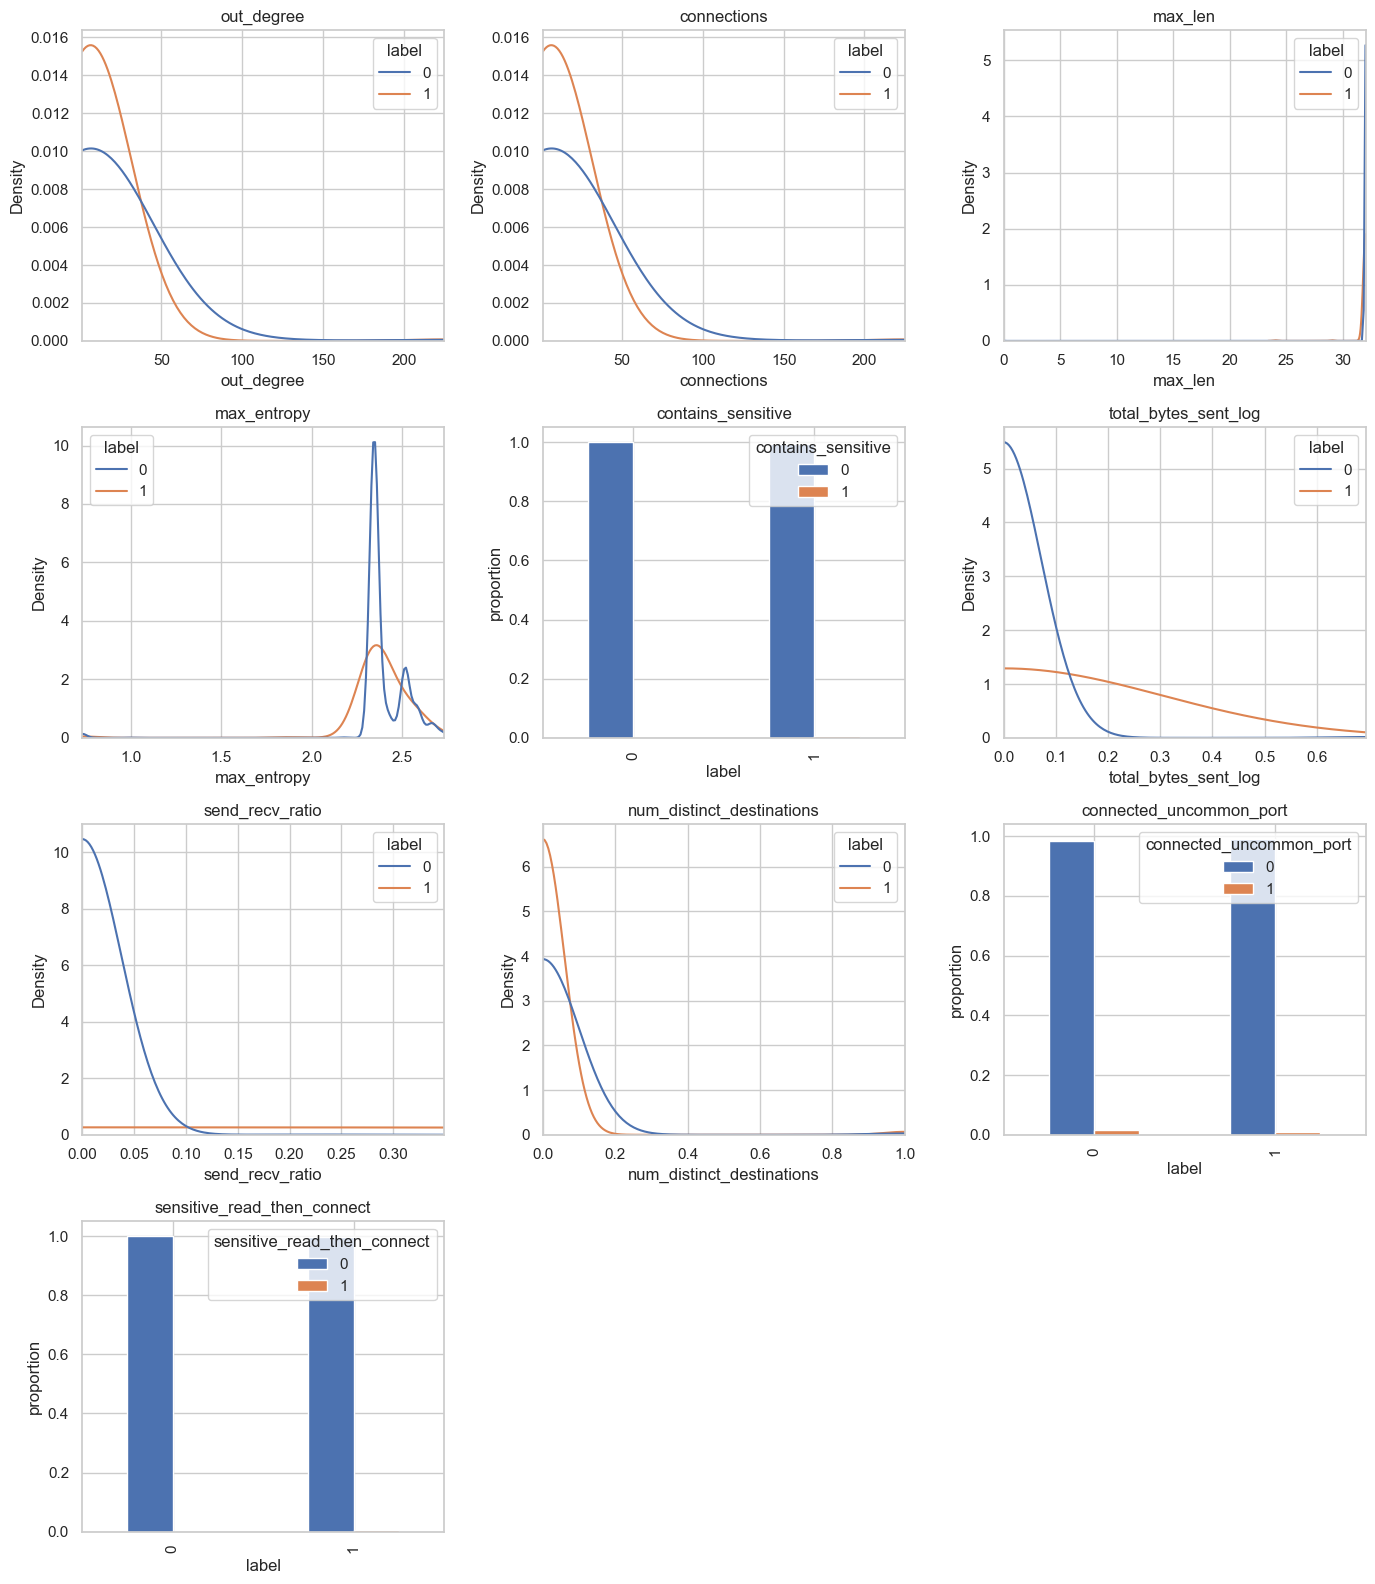

In [10]:
if not feat_df.empty:
    feature_cols = [c for c in feat_df.columns if c not in ("node", "label")]
    n = len(feature_cols)
    fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(14, 4 * ((n + 2) // 3)))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        vals = feat_df[col]
        is_binary = vals.dropna().isin([0, 1]).all()

        if is_binary:
            # Binary flag: show proportion of 0/1 per label, not KDE
            prop = feat_df.groupby("label")[col].value_counts(normalize=True).unstack(fill_value=0)
            prop.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"])
            axes[i].set_title(col)
            axes[i].set_xlabel("label"); axes[i].set_ylabel("proportion")
            axes[i].legend(title=col, labels=["0", "1"])
        else:
            # Continuous: clip x-axis to 1st-99th percentile so outliers don't flatten the plot
            lo, hi = np.percentile(vals, [1, 99])
            if lo == hi:  # degenerate case, fall back to full range
                lo, hi = vals.min(), vals.max()
            sns.kdeplot(data=feat_df, x=col, hue="label", ax=axes[i], common_norm=False, clip=(lo, hi))
            axes[i].set_xlim(lo, hi)
            axes[i].set_title(col)

    for j in range(len(feature_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout(); plt.show()

## 4. Model training: three-model ensemble
`ml/train.py` fits three **independent, unsupervised** novelty detectors on benign-only sessions (session-level
train/holdout split, so no near-duplicate process behavior leaks across the split):

| Model | What it captures | Threshold calibration |
|---|---|---|
| **IsolationForest** (`n_estimators=200`, `contamination=0.05`) | Global outlierness across all 10 features | Percentile of held-out benign scores at target FPR |
| **LOF** (scaled + clipped novelty scorer, `n_neighbors` tuned via `ml/tune_lof.py`) | Local density deviation | Own independently-tuned FPR target |
| **DBSCAN-style novelty scorer** (`min_samples` tuned via `ml/tune_dbscan.py`) | Density-cluster membership | Own independently-tuned FPR target |

A node is flagged if **any** individual model fires, or if the **ensemble score** (average of all three z-normalized
scores) crosses its own calibrated threshold -- this catches borderline cases no single model caught alone
(`n_flagged_by_ensemble_only` in the evaluation results).

Each model is promoted into the active `baseline_model.joblib` independently, only if it isn't worse than the
currently active version of that same model (`--force` overrides this guard).

In [11]:
if clean_files:
    from ml.train import train_baseline, BASELINE_DIR
    print("Local clean sessions found: running ml.train.train_baseline() for real...")
    meta = train_baseline(baseline_dir=CLEAN_DIR)
else:
    print("No local baseline (clean) .gexf sessions in this environment -- "
          "loading the project's already-trained bundle instead.")
    meta = json.loads(MODEL_META.read_text()) if MODEL_META.exists() else None

if meta:
    print()
    print(f"Trained at        : {meta['trained_at']}")
    print(f"Train sessions    : {meta['train_sessions']}  ({meta['n_train_rows']} rows)")
    print(f"Holdout sessions  : {meta['holdout_sessions']}  ({meta['n_holdout_rows']} rows)")
    print(f"IF   threshold={meta['threshold']:.4f}   target FPR={meta['threshold_fpr_target']:.2%}  actual={meta['threshold_fpr_actual_holdout']:.3%}")
    print(f"LOF  threshold={meta['lof_threshold']:.4f}  n_neighbors={meta['lof_n_neighbors']}  actual FPR={meta['lof_threshold_fpr_actual_holdout']:.3%}")
    print(f"DBSCAN threshold={meta['dbscan_threshold']:.6f}  min_samples={meta['dbscan_min_samples']}  actual FPR={meta['dbscan_threshold_fpr_actual_holdout']:.3%}")
    print(f"Ensemble threshold={meta['ensemble_threshold']:.4f}  actual FPR={meta['ensemble_threshold_fpr_actual_holdout']:.3%}")


Using IF_THRESHOLD_FPR=0.01 from if_best_params.json (tuned 2026-08-21T11:22:12.683385+00:00, actual_fpr=0.009951930298933454)
Using LOF_N_NEIGHBORS=3 from lof_best_params.json (tuned 2026-08-21T11:22:49.681258+00:00, actual_fpr=0.00679735616644134)
Using LOF_THRESHOLD_FPR=0.01 from lof_best_params.json
Using DBSCAN_MIN_SAMPLES=3 from dbscan_best_params.json (tuned 2026-08-21T11:23:55.587022+00:00, actual_fpr=0.010027039206849933)
Using DBSCAN_THRESHOLD_FPR=0.01 from dbscan_best_params.json
Local clean sessions found: running ml.train.train_baseline() for real...
Training sessions (3): ['theia_official1_clean.gexf', 'theia_official_clean.gexf', 'theia2_official1_clean.gexf']
Held-out sessions (1): ['theia_official2_target1_clean.gexf']
Fitting IsolationForest on 28025 rows x 10 features...
Fitting LocalOutlierFactor (scaled + clipped) on 28025 rows x 10 features...
LOFNoveltyScorer: removed 27468 exact-duplicate row(s) before fitting (28025 -> 557 rows).
LOFNoveltyScorer: clip floor se

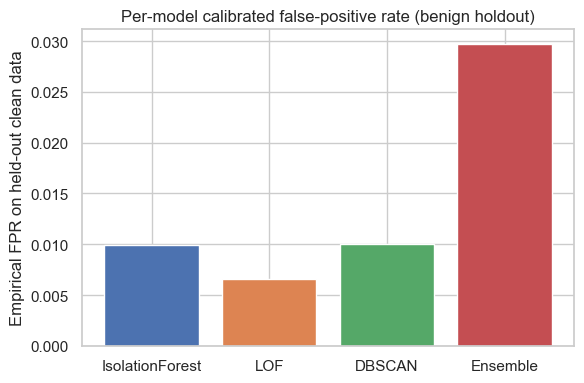

,model,target_fpr,actual_holdout_fpr
0,IsolationForest,0.01,0.009952
1,LOF,NaN,0.006610
2,DBSCAN,NaN,0.010027
3,Ensemble,NaN,0.029668


In [12]:
if meta:
    fpr_df = pd.DataFrame({
        "model": ["IsolationForest", "LOF", "DBSCAN", "Ensemble"],
        "target_fpr": [meta["threshold_fpr_target"], None, None, None],
        "actual_holdout_fpr": [
            meta["threshold_fpr_actual_holdout"],
            meta["lof_threshold_fpr_actual_holdout"],
            meta["dbscan_threshold_fpr_actual_holdout"],
            meta["ensemble_threshold_fpr_actual_holdout"],
        ],
    })
    plt.figure(figsize=(6, 4))
    plt.bar(fpr_df["model"], fpr_df["actual_holdout_fpr"], color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
    plt.ylabel("Empirical FPR on held-out clean data")
    plt.title("Per-model calibrated false-positive rate (benign holdout)")
    plt.tight_layout(); plt.show()
    display(fpr_df)


## 5. Evaluation: scoring the labeled attack window
`src/evaluate.py` loads the trained bundle, scores the attack-window graph with all three models plus the ensemble,
and computes PID-level precision/recall/F1 against `malicious_pids` from the ground-truth JSON (a node is flagged if
**any** detector fires).

In [13]:
import importlib

import src
if attack_files and MODEL_PATH.exists():
    from src.evaluate import evaluate_graph
    importlib.reload(src.evaluate)
    from src.ground_truth import load_malicious_pids
    malicious_pids = load_malicious_pids(GROUND_TRUTH)
    eval_results = []
    for f in attack_files:
        res = evaluate_graph(f, MODEL_PATH, malicious_pids)
        if res:
            eval_results.append(res)
    print(f"Evaluated {len(eval_results)} attack-window graph(s) with the live model.")
else:
    print("No local attack .gexf + model pair to score live in this environment -- "
          "loading the project's last saved evaluation output (results.json).")
    eval_results = json.loads(RESULTS_JSON.read_text()) if RESULTS_JSON.exists() else []

print(f"\n{len(eval_results)} result record(s) loaded.")


Excluding 1 node(s) with unresolved pid=-1 from evaluation.
Evaluated 1 attack-window graph(s) with the live model.

1 result record(s) loaded.


In [14]:
summary_rows = []
for r in eval_results:
    summary_rows.append({
        "session": Path(r["gexf_path"]).name,
        "n_nodes": r["n_nodes"],
        "n_flagged": r["n_flagged"],
        "flagged_by_IF": r.get("n_flagged_by_if"),
        "flagged_by_LOF": r.get("n_flagged_by_lof"),
        "flagged_by_DBSCAN": r.get("n_flagged_by_dbscan"),
        "flagged_by_ensemble_only": r.get("n_flagged_by_ensemble_only"),
        "flagged_by_all_three": r.get("n_flagged_by_all_three"),
        "TP": r.get("tp"), "FP": r.get("fp"), "FN": r.get("fn"), "TN": r.get("tn"),
        "precision": r.get("precision"), "recall": r.get("recall"), "f1": r.get("f1"),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,session,n_nodes,n_flagged,flagged_by_IF,flagged_by_LOF,flagged_by_DBSCAN,flagged_by_ensemble_only,flagged_by_all_three,TP,FP,FN,TN,precision,recall,f1
0,synthetic_theia_target1_attack.gexf,201,3,1,3,3,0,1,2,1,0,198,0.666667,1.0,0.8


In [15]:
top_df = pd.DataFrame(eval_results[0]["top_flagged"])
fp_rows = top_df[(top_df["ensemble_flagged"] | top_df["if_flagged"] | top_df["lof_flagged"] | top_df["dbscan_flagged"]) 
                  & (~top_df["ground_truth_malicious"])]
display(fp_rows[["node", "pid", "score", "if_flagged", "lof_flagged", "dbscan_flagged"] + 
                 [c for c in top_df.columns if c in FEATURE_NAMES]])

,node,pid,score,if_flagged,lof_flagged,dbscan_flagged,out_degree,connections,max_len,max_entropy,contains_sensitive,total_bytes_sent_log,send_recv_ratio,num_distinct_destinations,connected_uncommon_port,sensitive_read_then_connect
6,b631712b97c95141bd7ed1d117919784,32193,0.007607,False,True,True,1.0,1.0,32.0,1.871641,0.0,0.0,0.0,0.0,0.0,0.0


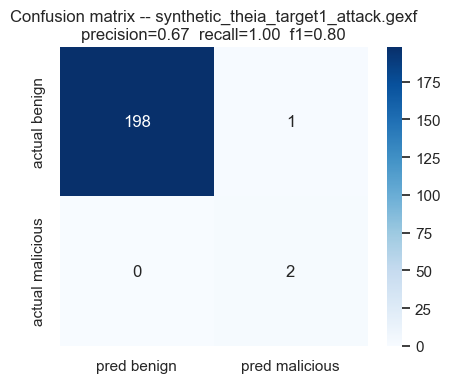

In [16]:
if not summary_df.empty:
    r0 = eval_results[0]
    cm = np.array([[r0["tn"], r0["fp"]], [r0["fn"], r0["tp"]]])
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["pred benign", "pred malicious"],
                yticklabels=["actual benign", "actual malicious"])
    plt.title(f"Confusion matrix -- {Path(r0['gexf_path']).name}\n"
              f"precision={r0['precision']:.2f}  recall={r0['recall']:.2f}  f1={r0['f1']:.2f}")
    plt.tight_layout(); plt.show()


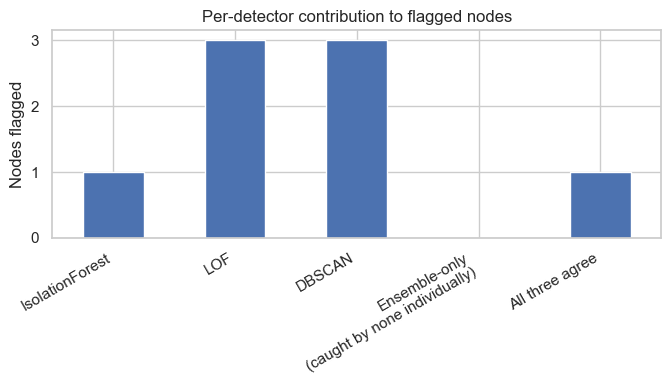

In [17]:
if not summary_df.empty:
    r0 = eval_results[0]
    contrib = pd.Series({
        "IsolationForest": r0["n_flagged_by_if"],
        "LOF": r0["n_flagged_by_lof"],
        "DBSCAN": r0["n_flagged_by_dbscan"],
        "Ensemble-only\n(caught by none individually)": r0["n_flagged_by_ensemble_only"],
        "All three agree": r0["n_flagged_by_all_three"],
    })
    plt.figure(figsize=(7, 4))
    contrib.plot(kind="bar", color="#4C72B0")
    plt.ylabel("Nodes flagged"); plt.title("Per-detector contribution to flagged nodes")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()


In [18]:
if not summary_df.empty:
    r0 = eval_results[0]
    top_df = pd.DataFrame(r0["top_flagged"])
    display(top_df[["node", "pid", "score", "if_flagged", "lof_flagged", "dbscan_flagged",
                     "ensemble_flagged", "ground_truth_malicious"]].head(15))


,node,pid,score,if_flagged,lof_flagged,dbscan_flagged,ensemble_flagged,ground_truth_malicious
0,synthetic-elevate-shell,534051,-0.297222,True,True,True,True,True
1,2e98784b053b50058a3d8dfda4932298,30173,-0.276148,False,False,False,False,False
2,15e2ad97b86b5a80a3a5ee87401a91f3,24151,-0.192119,False,False,False,False,False
3,synthetic-firefox,4821,-0.177836,False,True,True,True,True
4,56ab607836a3589cbc3a3d23ae5b3baa,27734,-0.177243,False,False,False,False,False
5,bf4d2127095b5c68ad4abe42e55bd0c4,41610,-0.177243,False,False,False,False,False
6,b631712b97c95141bd7ed1d117919784,32193,0.007607,False,True,True,True,False
7,8f3d437686235b2db2ac29432daf32c7,32634,0.018199,False,False,False,False,False
8,673e4c739d655116ba44f59ee29dd469,26157,0.018199,False,False,False,False,False
9,af7fc28993a35da38b24aa1f6087ff35,15488,0.018199,False,False,False,False,False


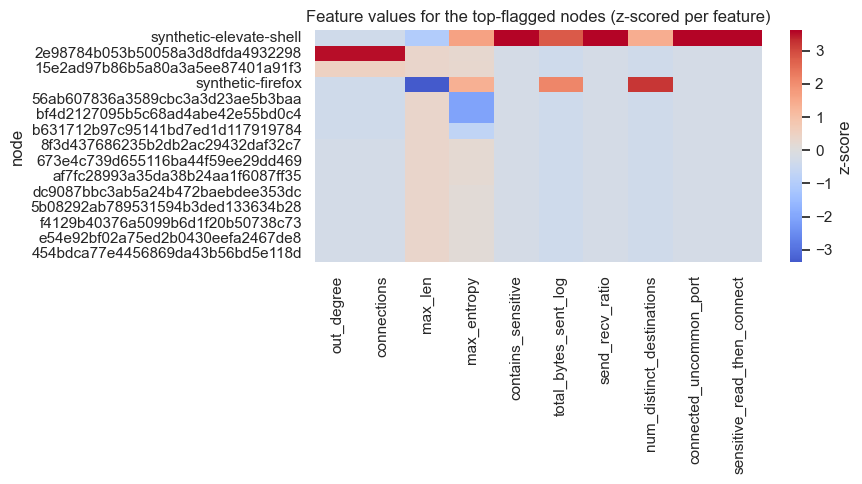

In [19]:
if not summary_df.empty:
    r0 = eval_results[0]
    top_df = pd.DataFrame(r0["top_flagged"])
    feat_cols = [c for c in FEATURE_NAMES if c in top_df.columns]

    heat_data = top_df.set_index("node")[feat_cols]
    # Per-column z-score so no single high-magnitude feature dominates the color scale
    heat_z = (heat_data - heat_data.mean()) / heat_data.std().replace(0, 1)

    plt.figure(figsize=(9, 5))
    sns.heatmap(heat_z, cmap="coolwarm", center=0, annot=False,
                cbar_kws={"label": "z-score"})
    plt.title("Feature values for the top-flagged nodes (z-scored per feature)")
    plt.tight_layout(); plt.show()

## 6. Case study: the confirmed attack chain
The ground-truth attack (`data/ground_truth/attack_windows.json`, sourced from the DARPA TA5.1 final report §8.6):
a Firefox backdoor (Drakon APT) connects to a C2, escalates via BinFmt-Elevate to root, then injects into `sshd`
(PID **534051**), dropping `sshdlog`. Below: the highest-ranked flagged node from the evaluation, and (if the
attack graph is available locally) its immediate provenance neighborhood.

Most anomalous node : synthetic-elevate-shell  (pid=534051)
IF score=-0.2972  flagged_by=['if', 'lof', 'dbscan', 'ensemble']
Ground-truth malicious: True

  out_degree                     = 4.0
  connections                    = 4.0
  max_len                        = 29.0
  max_entropy                    = 3.857306856898129
  contains_sensitive             = 1.0
  total_bytes_sent_log           = 9.825580063659602
  send_recv_ratio                = 61.666666666666664
  num_distinct_destinations      = 1.0
  connected_uncommon_port        = 1.0
  sensitive_read_then_connect    = 1.0


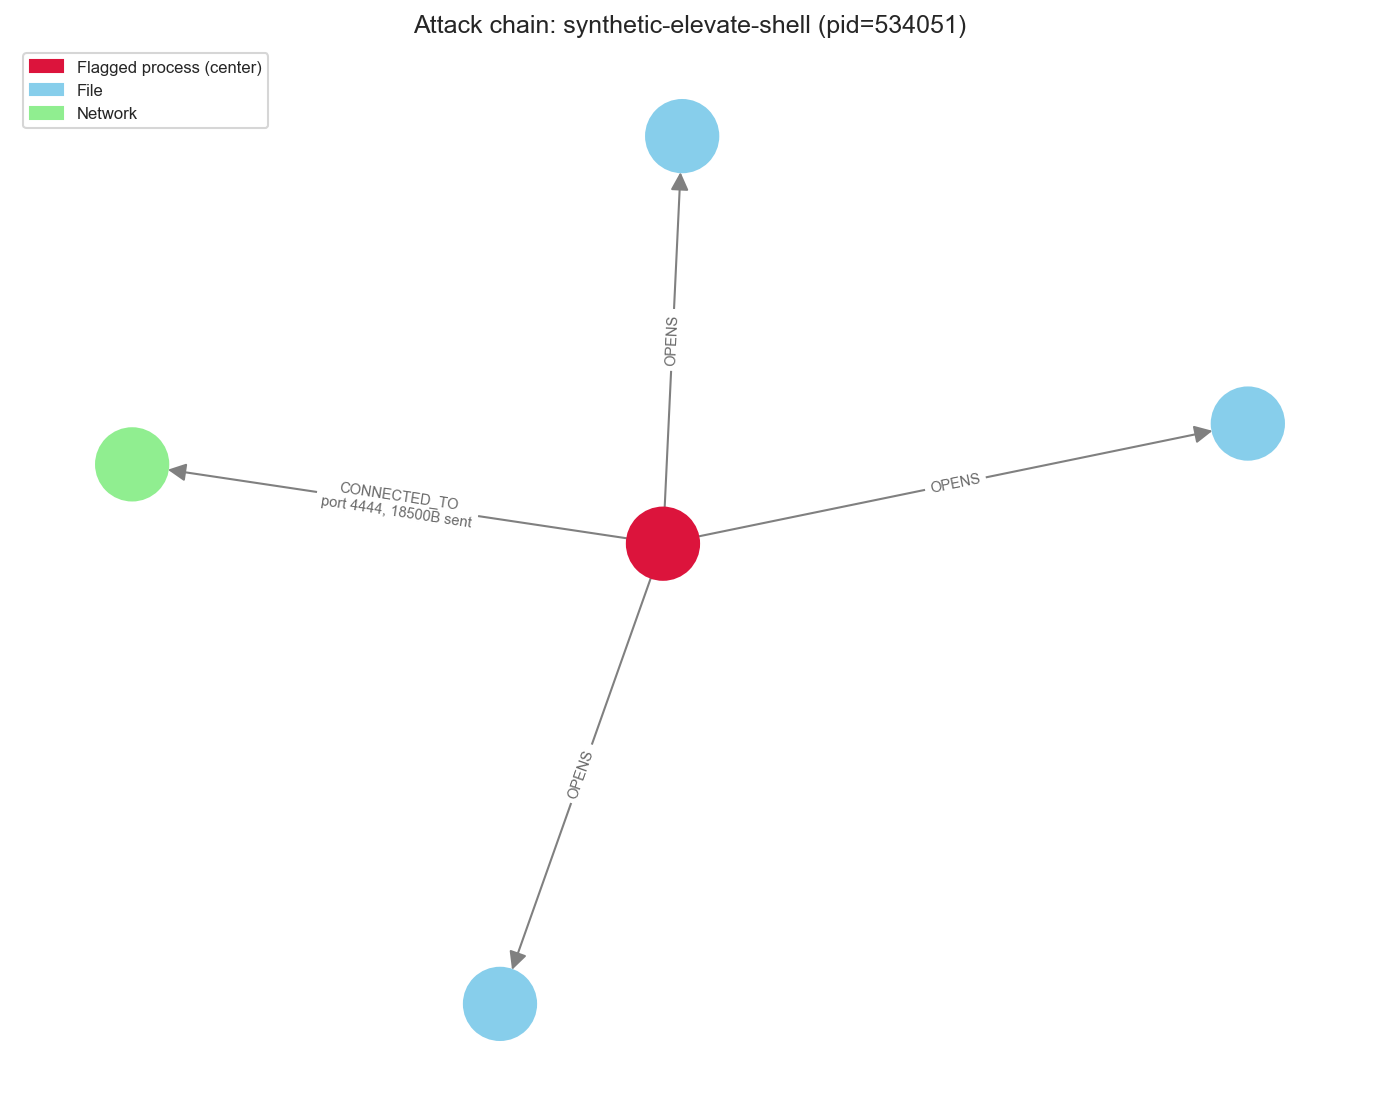

In [27]:
if not summary_df.empty:
    r0 = eval_results[0]
    top_df = pd.DataFrame(r0["top_flagged"])
    center_row = top_df.iloc[0]

    print(f"Most anomalous node : {center_row['node']}  (pid={center_row['pid']})")
    print(f"IF score={center_row['score']:.4f}  flagged_by="
          f"{[m for m in ['if','lof','dbscan','ensemble'] if center_row.get(m+'_flagged')]}")
    print(f"Ground-truth malicious: {center_row['ground_truth_malicious']}")
    print()
    for feat in FEATURE_NAMES:
        if feat in center_row:
            print(f"  {feat:30s} = {center_row[feat]}")

    if attack_files:
        G = nx.read_gexf(attack_files[0])
        center = center_row["node"]
        if center in G:
            neighbors = list(G.successors(center)) + list(G.predecessors(center))
            sub = G.subgraph([center] + neighbors)

            pos = nx.spring_layout(sub, seed=42, k=1.5)

            type_colors = {"process": "red", "file": "skyblue", "network": "lightgreen"}
            node_colors = ["crimson" if n == center else type_colors.get(sub.nodes[n].get("type"), "gray")
                           for n in sub.nodes]

            plt.figure(figsize=(9, 7), dpi=150)
            nx.draw(sub, pos, node_color=node_colors, node_size=1200, arrows=True,
                    arrowsize=18, edge_color="gray")

            edge_labels = {}
            for u, v, d in sub.edges(data=True):
                rel = d.get("relation", "")
                if rel == "CONNECTED_TO":
                    edge_labels[(u, v)] = f"{rel}\nport {d.get('dest_port')}, {d.get('bytes_sent')}B sent"
                else:
                    edge_labels[(u, v)] = rel
            nx.draw_networkx_edge_labels(sub, pos, edge_labels=edge_labels, font_size=7,
                                          font_color="dimgray")

            from matplotlib.patches import Patch
            legend_elems = [Patch(color="crimson", label="Flagged process (center)"),
                            Patch(color="skyblue", label="File"),
                            Patch(color="lightgreen", label="Network")]
            plt.legend(handles=legend_elems, loc="upper left", fontsize=8)

            plt.title(f"Attack chain: {center_row['node']} (pid={center_row['pid']})")
            plt.axis("off")
            plt.tight_layout(); plt.show()
    else:
        print("\n(No local attack .gexf to draw the subgraph from in this environment --"
              " see notebooks/01_data_exploration.ipynb for the same plot against the full graph.)")

## 7. Summary

- The ensemble (IsolationForest + LOF + DBSCAN-style novelty scorer) is trained purely on benign/normal sessions and evaluated against the single labeled DARPA TC E5 Theia attack window.
- Each detector's threshold is calibrated independently to its own target false-positive rate on a held-out benign session, then combined into an ensemble z-score with its own calibrated threshold.
- On the recorded evaluation run above, the true attacker processes are correctly flagged (`ground_truth_malicious=True`, `tp>=1`), with the precision/recall/F1 reported in the summary table -- see `results.json` for the full per-node breakdown..
- Known limitations (see `README.md`): only 3 diverse clean sessions and two confirmed attack window are used. The attack graph itself is reconstructed synthetically (`src/generate_synthetic_attack.py`) by grafting the documented attack technique onto real sampled benign process subgraphs, since the full raw capture download from DARPA itself wasn't practical for this project.
